This notebook was made for plotting nBodySimulation results.

In [120]:
import subprocess
import os
import json
import pandas as pd
import matplotlib.pyplot as plt


Choose which methods to include. The currently supported options are vulkan_cells, vulkan_naive, cpp_naive

Also choose whether or not to force rerun the benchmarks. Alternatively, old runs will be used (if available)

In [121]:
incl = ["vulkan_cells", "vulkan_naive", "cpp_naive"]
force_rerun = False

executables = {
    "vulkan_cells" : "../build/src/nBodySimulation/vulkan/cell_lists/nbody_vulkan_cells",
    "vulkan_naive" : "../build/src/nBodySimulation/vulkan/naive/nbody_vulkan_naive",
    "cpp_naive"    : "../build/src/nBodySimulation/cpp/nbody_cpp"
}

results = {
    "vulkan_cells" : "../results/nBody_vulkan_cells.json",
    "vulkan_naive" : "../results/nBody_vulkan_naive.json",
    "cpp_naive"    : "../results/nBody_cpp_naive.json"
}
        

In [122]:
def run_benchmark(method):
    print("Now running " + method + " benchmark...")
    executable_path = executables[method]
    result_path = results[method]
    command = [executable_path, f"--benchmark_out={result_path}", "--benchmark_out_format=json"]
    result = subprocess.run(command, capture_output=True, text=True, check=True)
    print(result.stdout, "\n")

def file_exists(filepath):
    return os.path.exists(filepath)

def validate_json_file(method):
    try:
        with open(results[method]) as f:
            json.load(f)
        return True
    except:
        return False
        

In [123]:
if force_rerun:
    for method in incl:
        if not file_exists(executables[method]):
            raise FileNotFoundError(f"The executable for {method} was not found in the build directory. Reconfigure the project to build the correct files!")
    for method in incl:
        run_benchmark(method=method)
else:
    for method in incl:
        if not file_exists(results[method]):
            print(f"Could not find results for {method}...")
            if not file_exists(executables[method]):
                raise FileNotFoundError(f"The executable for {method} was not found in the build directory. Reconfigure the project to build the correct files!")
            run_benchmark(method)
        if not validate_json_file(method):
            print(f"Could not validate json results file for {method}.")
            run_benchmark(method)

for method in incl:
    if not validate_json_file(method):
        raise FileNotFoundError(f"The result file for {method} was not found or could not be opened.")
        

Could not validate json results file for vulkan_naive.
Now running vulkan_naive benchmark...
------------------------------------------------------------------------------------------
Benchmark                                Time             CPU   Iterations UserCounters...
------------------------------------------------------------------------------------------
NBody-Float-Vulkan-Naive/10     2930391309 ns   2659790170 ns            1 cells_setup=0 force_update=709.435M position_update_reset=710.199M velocity_update=706.376M
NBody-Float-Vulkan-Naive/100    2851124582 ns   2589639262 ns            1 cells_setup=0 force_update=693M position_update_reset=692.513M velocity_update=687.299M
NBody-Float-Vulkan-Naive/1000   3083790846 ns   2652923336 ns            1 cells_setup=0 force_update=864.313M position_update_reset=711.582M velocity_update=706.005M
NBody-Float-Vulkan-Naive/10000  4470112492 ns   2617275951 ns            1 cells_setup=0 force_update=2.27788G position_update_reset=626.

Now all results should exist. Next the files need to be read.


In [124]:
def add_problem_size_column(df):
    df = df.copy()
    df["N"] = df["name"].str.extract(r"/(\d+)$").astype(int)
    return df
    

In [125]:
dataframes = {}
for method in incl:
    with open(results[method], 'r') as f:
        data = json.load(f)
    benchmarks = data["benchmarks"]
    
    df = pd.DataFrame(benchmarks)
    df = df[df["run_type"] == "iteration"]
    df = df.drop(columns=["family_index", "per_family_instance_index", "run_name", 
        "run_type", "repetitions", "repetition_index", 
        "threads", "iterations", "cpu_coefficient", 
        "real_coefficient", "big_o", "rms", 
        "aggregate_name", "aggregate_unit"])
    df["real_time_s"] = df["real_time"] / 1e9
    df["cpu_time_s"]  = df["cpu_time"]  / 1e9

    dataframes[method] = add_problem_size_column(df)
    

Now we display the results in matplotlib graphs.

In [126]:
def plot_single(df, title, git_hash=None):
    plt.figure(figsize=(8,5))
    plt.plot(df["N"], df["real_time_s"], marker="o")
    plt.xscale("log")
    plt.xlabel("N (problem size)")
    plt.ylabel("Real time (s)")
    plt.title(title)
    plt.grid(True)

    if git_hash:
        plt.figtext(
            0.5, -0.05,
            f"git hash: {git_hash}",
            ha="center", fontsize=8, color="gray"
        )

    plt.show()

def plot_overlay(dataframes, git_hash=None):
    plt.figure(figsize=(8,5))

    for label, df in dataframes.items():
        df = add_problem_size_column(df)     # if needed in your workflow
        plt.plot(df["N"], df["real_time_s"], marker="o", label=label)

    plt.xscale("log")
    plt.xlabel("N (problem size)")
    plt.ylabel("Real time (s)")
    plt.title("Benchmark Comparison")
    plt.grid(True)
    plt.legend()

    if git_hash:
        plt.figtext(
            0.5, -0.05,
            f"git hash: {git_hash}",
            ha="center", fontsize=8, color="gray"
        )

    plt.show()


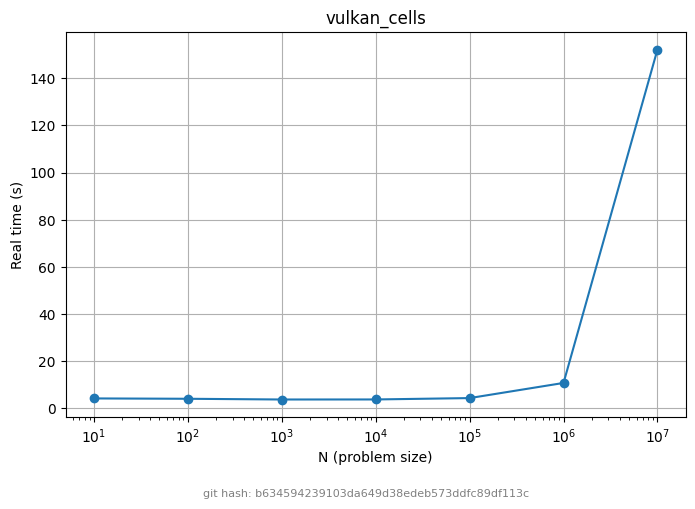

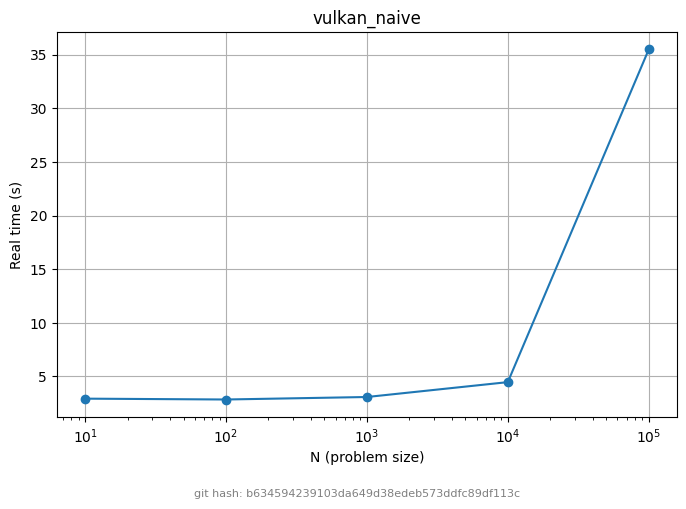

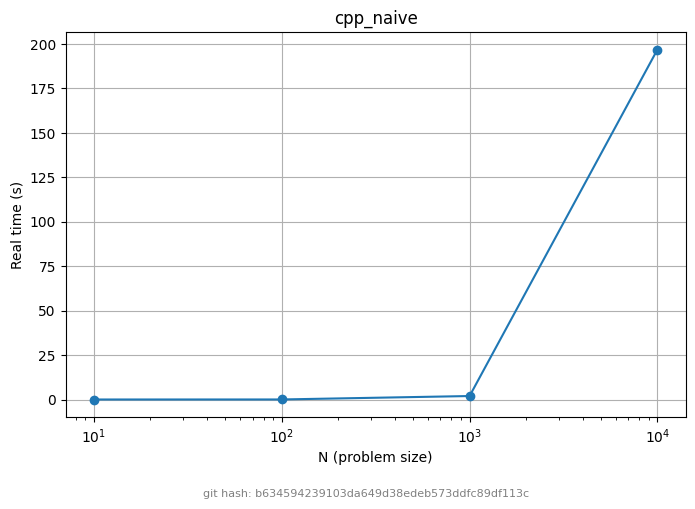

In [127]:
git_hash = subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip()

for method in incl:
    plot_single(dataframes[method], method, git_hash)

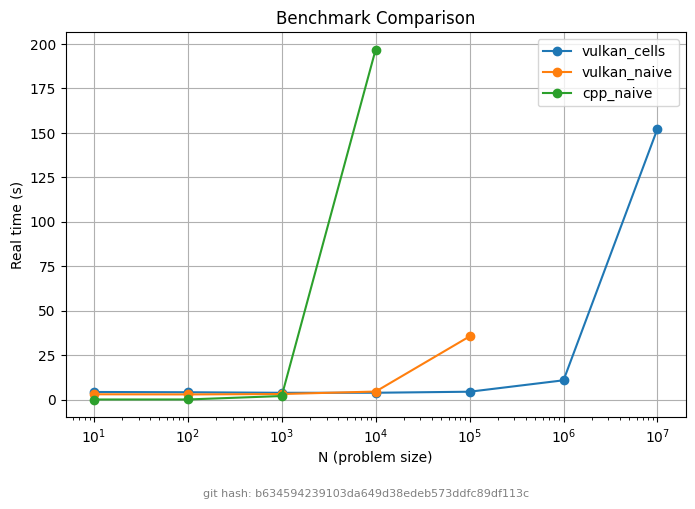

In [128]:
plot_overlay(dataframes, git_hash)